# NoisiQ — Week 5 Notebook
**Noise-Aware Quantum Circuit Simulation and Visualization**
*Period: April 20 – April 26, 2026*

---

## Purpose of This Notebook

This notebook demonstrates the Week 5 deliverables using a **4-qubit GHZ state** as the
running example. The GHZ circuit (`H → CNOT(0,1) → CNOT(1,2) → CNOT(2,3)`) is ideal
because an X error injected on q0 after the Hadamard fans out through every CNOT in the
chain, making error propagation immediately visible.

By the end of this notebook you should be able to:
- Build and display a clean Quirk-style circuit diagram with `draw_circuit`
- Step through single-shot error propagation with errors riding the wire at each time step
- Use Play/Pause, Step Forward/Back, and Speed controls via `Visualizer.animate()`
- Inspect per-gate info for single-shot and many-shot results with `GateInfoExtractor`
- Export the animation as a GIF or self-contained HTML file
- Confirm all 14 gate conjugation correctness tests pass

---

## Status Tracker

| Task | Owner | Status |
|------|-------|--------|
| `noisiq/visualization/theme.py` — Quirk palette finalized | DS | ✅ Done |
| `noisiq/visualization/circuit_diagram.py` — upgraded static diagram | DS | ✅ Done |
| `noisiq/visualization/drawer.py` — errors step with animation column | DS | ✅ Done |
| `noisiq/visualization/animation.py` — play/pause/step/speed controls | DS | ✅ Done |
| `noisiq/visualization/export.py` — `export_gif()` and `export_html()` | DS | ✅ Done |
| `noisiq/visualization/gate_info.py` — single/many-shot hover dispatch | DS | ✅ Done |
| `noisiq/visualization/widgets.py` — `run_many()` + hover tooltip | DS | ✅ Done |
| `tests/backends/test_stim_correctness.py` — 14 gate conjugation tests | DS | ✅ Done |
| All tests passing via `pytest` (78 total) | DS | ✅ Done |
| Week 5 demo notebook complete | DS | ✅ Done |

---

## Notes and Decisions Log

| Date | Note | Name |
|------|------|------|
| 2026-05-03 | Error labels now step with the animation column — each error sits at the same x-position as the currently highlighted gate, on its qubit wire. This makes errors from earlier gates (e.g. q2 after the first H) remain visible and slide forward with each step. | DS |
| 2026-05-03 | `circuit_diagram.py` added as the clean static renderer. `drawer.py` remains as the step-aware renderer used in `Visualizer.show()`. `animation.py` uses `draw_circuit` (circuit_diagram.py) for the full animation loop. | DS |
| 2026-05-03 | `GateInfoExtractor` is stateless — dispatches on `isinstance(result, AggregateResult)`. No manual mode flag needed in `widgets.py`. | DS |

In [9]:
# ── Week 5 Setup ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

from noisiq.ir import Circuit, gates
from noisiq.noise.pauli_channels import DepolarizingChannel, BitFlipChannel
from noisiq.backends.many_shot_runner import ManyShotRunner
from noisiq.visualization import (
    draw_circuit,
    Visualizer,
    CircuitAnimator,
    export_gif,
    export_html,
    GateInfoExtractor,
    apply_global_style,
)

apply_global_style()
print("NoisiQ Week 5 — ready")

NoisiQ Week 5 — ready


---
## 1 — Build the 4-Qubit GHZ Circuit

Standard chain construction:
```
t=0  H on q1 through q4
t=1  CNOT(q0 → q1)
t=2  CNOT(q1 → q2)
t=3  CNOT(q2 → q3)
```
Noise model: bit-flip (X-only) on the H gate so we get a clean X error on q0;
depolarizing on each CNOT to show mixed propagation.

In [10]:
ghz = (
    Circuit(4, name="ghz_4q")
    .h(0)           # t=0
    .h(1)           # t=0
    .h(2)           # t=0
    .h(3)           # t=0
    .cnot(0, 1)     # t=1
    .cnot(1, 2)     # t=2
    .cnot(2, 3)     # t=3
)

# Noise: guaranteed X error on q0 after H; depolarizing p=0.15 on each CNOT
noise_map = {
    0: BitFlipChannel(p=1.0).to_pauli_error(),     # H  → always X on q0
    1: DepolarizingChannel(p=0.15).to_pauli_error(), # CNOT(0,1)
    2: DepolarizingChannel(p=0.15).to_pauli_error(), # CNOT(1,2)
    3: DepolarizingChannel(p=0.15).to_pauli_error(), # CNOT(2,3)
}

print(ghz)
for i, op in enumerate(ghz.operations):
    print(f"  op[{i}]  t={op.t}  {op.gate.name}  q{list(op.qubits)}")

Circuit(n_qubits=4, operations=[Operation(gate='H', qubits=(0,), t=0), Operation(gate='H', qubits=(1,), t=0), Operation(gate='H', qubits=(2,), t=0), Operation(gate='H', qubits=(3,), t=0), Operation(gate='CNOT', qubits=(0, 1), t=1), Operation(gate='CNOT', qubits=(1, 2), t=2), Operation(gate='CNOT', qubits=(2, 3), t=3)], name='ghz_4q')
  op[0]  t=0  H  q[0]
  op[1]  t=0  H  q[1]
  op[2]  t=0  H  q[2]
  op[3]  t=0  H  q[3]
  op[4]  t=1  CNOT  q[0, 1]
  op[5]  t=2  CNOT  q[1, 2]
  op[6]  t=3  CNOT  q[2, 3]


---
## 2 — Static Circuit Diagram (`circuit_diagram.py`)

`draw_circuit` renders a clean Quirk-style diagram: gate boxes colored by category,
tight column spacing, qubit labels on the left, timestep labels on top.

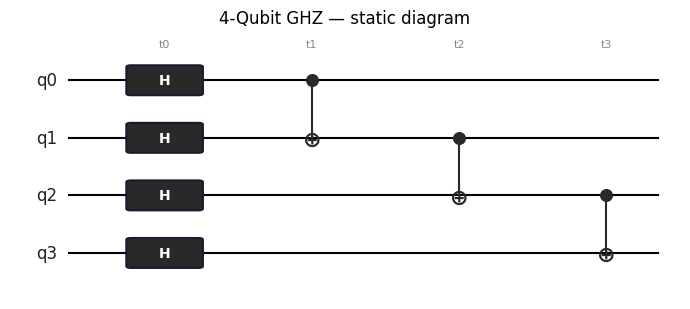

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.2))
draw_circuit(ax, ghz, title="4-Qubit GHZ — static diagram")
plt.tight_layout()
plt.show()

---
## 3 — Single-Shot Error Propagation (`Visualizer.show()`)

The X error injected on q0 at t=0 (H gate) propagates through the CNOT chain:
- **t=0** H: X error injected on q0
- **t=1** CNOT(0→1): X on control spreads X to target → both q0 and q1 carry X
- **t=2** CNOT(1→2): X on q1 spreads to q2
- **t=3** CNOT(2→3): X on q2 spreads to q3

Each error label sits at the current animation column's x-position on its qubit wire,
stepping forward with the slider even on qubits with no gate at that time step.

In [12]:
viz = Visualizer(ghz)
viz.simulate(noise_config=noise_map, seed=0)
viz.show()

---
## 4 — Animation Controls (`Visualizer.animate()`)

The `animate()` method launches `CircuitAnimator.show()` which provides:
- **▶ Play / ⏸ Pause** toggle button
- **◀ Step / Step ▶** buttons for single-frame stepping
- **FPS slider** (1–10 frames per second)
- Frame counter label

In [13]:
viz.animate()

---
## 5 — Gate Info Extractor — Single-Shot

`GateInfoExtractor.for_gate(op_idx, result)` returns a dict of hover fields.
In single-shot mode: gate type, qubits, timestep, and any exact errors that occurred.

In [14]:
single_result = viz.result

print("=== Single-shot gate info ===")
for op_idx in range(len(ghz.operations)):
    info = GateInfoExtractor.for_gate(op_idx, single_result)
    print(f"\nop[{op_idx}]")
    print(GateInfoExtractor.format_for_display(info))

=== Single-shot gate info ===

op[0]
Gate:     H  (t=0)
Qubits:   [0]
Error:    X on q0

op[1]
Gate:     H  (t=0)
Qubits:   [1]
Error:    none

op[2]
Gate:     H  (t=0)
Qubits:   [2]
Error:    X on q2

op[3]
Gate:     H  (t=0)
Qubits:   [3]
Error:    X on q3

op[4]
Gate:     CNOT  (t=1)
Qubits:   [0, 1]
Error:    none

op[5]
Gate:     CNOT  (t=2)
Qubits:   [1, 2]
Error:    none

op[6]
Gate:     CNOT  (t=3)
Qubits:   [2, 3]
Error:    none


---
## 6 — Many-Shot Run + Gate Info Extractor

`Visualizer.run_many()` wraps `ManyShotRunner` and stores the `AggregateResult`.
`GateInfoExtractor` automatically switches to many-shot fields when given an
`AggregateResult`: per-qubit error rates, most-likely error, and fidelity estimate.

In [15]:
many_result = viz.run_many(n_shots=1000, noise_config=noise_map, seed=42)

print(f"Many-shot run: {many_result.n_shots} shots")
print(f"Zero-error fraction: {many_result.zero_error_fraction:.3f}")

print("\n=== Many-shot gate info ===")
for op_idx in range(len(ghz.operations)):
    info = GateInfoExtractor.for_gate(op_idx, many_result)
    print(f"\nop[{op_idx}]")
    print(GateInfoExtractor.format_for_display(info))

Many-shot run: 1000 shots
Zero-error fraction: 0.000

=== Many-shot gate info ===

op[0]
Gate:     H  (t=0)
Qubits:   [0]
Shots:    1000
  q0: 1.000
Top error: q0  (1.000)
Fidelity: 0.0000

op[1]
Gate:     H  (t=0)
Qubits:   [1]
Shots:    1000
  q1: 0.147
Top error: q1  (0.147)
Fidelity: 0.8530

op[2]
Gate:     H  (t=0)
Qubits:   [2]
Shots:    1000
  q2: 0.155
Top error: q2  (0.155)
Fidelity: 0.8450

op[3]
Gate:     H  (t=0)
Qubits:   [3]
Shots:    1000
  q3: 0.150
Top error: q3  (0.150)
Fidelity: 0.8500

op[4]
Gate:     CNOT  (t=1)
Qubits:   [0, 1]
Shots:    1000
Fidelity: 1.0000

op[5]
Gate:     CNOT  (t=2)
Qubits:   [1, 2]
Shots:    1000
Fidelity: 1.0000

op[6]
Gate:     CNOT  (t=3)
Qubits:   [2, 3]
Shots:    1000
Fidelity: 1.0000


---
## 7 — Export Animation (GIF + HTML)

`export_gif` uses Pillow; `export_html` produces a self-contained page with
embedded JavaScript playback controls — no additional dependencies needed to view it.

In [16]:
import os
os.makedirs("outputs", exist_ok=True)

animator = CircuitAnimator(ghz, single_result, viz.trajectories)
anim = animator.to_func_animation(interval_ms=500)

export_gif(anim, "outputs/ghz_week5.gif", fps=2)
export_html(anim, "outputs/ghz_week5.html", fps=2)
plt.close("all")

GIF saved → outputs/ghz_week5.gif
HTML saved → outputs/ghz_week5.html
